# Variante 3: Multiprocessing Dynamic

Worker holen sich dynamisch neue Bilder aus einer internen Queue, sobald sie frei sind.

Hypothese: Dynamic ist bei variabler Auflösung (Kaggle Pneumonia) im Vorteil, weil kein Prozess idle wartet während ein anderer noch ein großes Bild verarbeitet. Bei gleicher Auflösung (NIH) bringt Dynamic keinen Vorteil.

Technologie: multiprocessing.Pool mit imap_unordered (chunksize=1)

#### Imports

In [1]:
import sys
from scipy import stats

import multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import statistics
from pathlib import Path
from functools import partial

from pipeline import process_image, get_image_paths

print(f"CPU-Kerne verfügbar: {multiprocessing.cpu_count()}")

CPU-Kerne verfügbar: 16


#### Konfiguration
Hinweis: Bitte an eigenes lokales Set-Up anpassen
(Laptop 1 = Maxim, Laptop 2 = Ella, Laptop 3 = Jordan)

In [2]:
LAPTOP_ID = 2

IMG_SIZE = (512, 512)
RUNS = 10

NIH_DIR    = "../data/nih_chest_xray"
KAGGLE_DIR = "../data/kaggle_pneumonia"

RESULTS_DIR = f"results/laptop{LAPTOP_ID}"
RESULTS_CSV = f"{RESULTS_DIR}/results_dynamic_laptop{LAPTOP_ID}.csv"

IMAGE_COUNTS   = [100, 500, 1000, 5000]
PROCESS_COUNTS = [1, 2, 4, 8]
CHUNKSIZE      = 1 #Chunksize 1 damit jeder Worker ein Bild verarbeitet, höhere Chunksize wäre weniger Queue-Kommunikation aber weniger Lastausgleich, nähert sich Static an

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

#### 1. Get Images

In [3]:
nih_paths    = get_image_paths(NIH_DIR)
kaggle_paths = get_image_paths(KAGGLE_DIR)

print(f"NIH Bilder gefunden:              {len(nih_paths)}")
print(f"Kaggle Pneumonia Bilder gefunden: {len(kaggle_paths)}")

NIH Bilder gefunden:              10000
Kaggle Pneumonia Bilder gefunden: 5216


#### 2. Process Image
- **process_image** gibt ein Dictionary zurück und Pool leitet es direkt ans Hauptprogramm weiter. Hier brauchen wir kein manager.list() shared memory wie bei static.
- **with multiprocessing.Pool() as pool** Am Ende des with-Blocks wird der Pool automatisch geschlossen und alle Worker-Prozesse beendet. Ohne with müssten wir pool.close() und pool.join() manuell aufrufen

In [4]:
def run_dynamic(image_paths, n_processes, chunksize=1):
    t_start = time.perf_counter()
    with multiprocessing.Pool(processes=n_processes) as pool:
        results = list(pool.imap_unordered(process_image, image_paths, chunksize=chunksize)) #unordered ist etwas effizienter, Reihenfolge der Ergebnisse ist nicht wichtig
    total_time = time.perf_counter() - t_start
    return total_time, results

In [ ]:
#### 2b. "True" Dynamic (explizite Queue)
Echtes dynamisches Scheduling mit multiprocessing.Queue.
Jeder Worker holt sich aktiv die nächste Aufgabe (kein Pool-internes Management).

In [ ]:
def worker_dynamic_true(task_queue, result_queue):
    while True:
        path = task_queue.get()  # holt nächste Aufgabe aus Queue
        if path is None:         # Sentinel — keine Arbeit mehr
            break
        result = process_image(path)
        result_queue.put(result)


def run_dynamic_true(image_paths, n_processes):
    task_queue   = multiprocessing.Queue()
    result_queue = multiprocessing.Queue()

    for path in image_paths:
        task_queue.put(path)

    # ein None pro Prozess als Stoppsignal
    for _ in range(n_processes):
        task_queue.put(None)

    processes = [
        multiprocessing.Process(
            target=worker_dynamic_true,
            args=(task_queue, result_queue)
        )
        for _ in range(n_processes)
    ]

    t_start = time.perf_counter()
    for p in processes: p.start()
    for p in processes: p.join()
    total_time = time.perf_counter() - t_start

    results = []
    while not result_queue.empty():
        results.append(result_queue.get())

    return total_time, results

#### 3. Run

In [5]:
def benchmark():
    rows = []

    datasets = [
        ("NIH",              nih_paths),
        ("Kaggle Pneumonia", kaggle_paths),
    ]

    for dataset_name, all_paths in datasets:
        print(f"\n=== {dataset_name} ===")

        for n_img in IMAGE_COUNTS:
            subset = all_paths[:n_img]
            if len(subset) < n_img:
                print(f"  Nur {len(subset)} Bilder verfügbar (angefragt: {n_img})")
                continue

            for n_proc in PROCESS_COUNTS:
                # Dynamic (Pool)
                runtimes = []
                for run in range(RUNS):
                    runtime, _ = run_dynamic(subset, n_proc, chunksize=CHUNKSIZE)
                    runtimes.append(runtime)

                median_runtime    = statistics.median(runtimes)
                median_throughput = n_img / median_runtime
                std_runtime       = statistics.stdev(runtimes)
                ci                = stats.t.interval(0.95, df=len(runtimes)-1, loc=median_runtime, scale=stats.sem(runtimes))

                rows.append({
                    "Laptop":        LAPTOP_ID,
                    "Variante":      "Dynamic",
                    "Datensatz":     dataset_name,
                    "Bilder":        n_img,
                    "Prozesse":      n_proc,
                    "Laufzeit in s": round(median_runtime, 3),
                    "Std":           round(std_runtime, 4),
                    "CI_low":        round(ci[0], 4),
                    "CI_high":       round(ci[1], 4),
                    "Speedup":       None,
                    "Efficiency":    None,
                    "Throughput":    round(median_throughput, 2),
                    "all_times": str(runtimes),
                })
                print(f"  {n_img} Bilder | {n_proc} Prozesse | Dynamic | Median: {median_runtime:.3f}s ± {std_runtime:.4f}s")

                # Dynamic True (explizite Queue)
                runtimes = []
                for run in range(RUNS):
                    runtime, _ = run_dynamic_true(subset, n_proc)
                    runtimes.append(runtime)

                median_runtime    = statistics.median(runtimes)
                median_throughput = n_img / median_runtime
                std_runtime       = statistics.stdev(runtimes)
                ci                = stats.t.interval(0.95, df=len(runtimes)-1, loc=median_runtime, scale=stats.sem(runtimes))

                rows.append({
                    "Laptop":        LAPTOP_ID,
                    "Variante":      "Dynamic True",
                    "Datensatz":     dataset_name,
                    "Bilder":        n_img,
                    "Prozesse":      n_proc,
                    "Laufzeit in s": round(median_runtime, 3),
                    "Std":           round(std_runtime, 4),
                    "CI_low":        round(ci[0], 4),
                    "CI_high":       round(ci[1], 4),
                    "Speedup":       None,
                    "Efficiency":    None,
                    "Throughput":    round(median_throughput, 2),
                    "all_times": str(runtimes),
                })
                print(f"  {n_img} Bilder | {n_proc} Prozesse | Dynamic True | Median: {median_runtime:.3f}s ± {std_runtime:.4f}s")

    return pd.DataFrame(rows)

df = benchmark()
df


=== NIH ===
  100 Bilder | 1 Prozesse | Median: 0.674s
  100 Bilder | 2 Prozesse | Median: 0.359s
  100 Bilder | 4 Prozesse | Median: 0.222s
  100 Bilder | 8 Prozesse | Median: 0.173s
  500 Bilder | 1 Prozesse | Median: 3.362s
  500 Bilder | 2 Prozesse | Median: 1.851s
  500 Bilder | 4 Prozesse | Median: 1.094s
  500 Bilder | 8 Prozesse | Median: 0.739s
  1000 Bilder | 1 Prozesse | Median: 6.694s
  1000 Bilder | 2 Prozesse | Median: 3.671s
  1000 Bilder | 4 Prozesse | Median: 2.137s
  1000 Bilder | 8 Prozesse | Median: 1.409s
  5000 Bilder | 1 Prozesse | Median: 33.969s
  5000 Bilder | 2 Prozesse | Median: 18.399s
  5000 Bilder | 4 Prozesse | Median: 10.722s
  5000 Bilder | 8 Prozesse | Median: 6.899s

=== Kaggle Pneumonia ===
  100 Bilder | 1 Prozesse | Median: 0.916s
  100 Bilder | 2 Prozesse | Median: 0.524s
  100 Bilder | 4 Prozesse | Median: 0.336s
  100 Bilder | 8 Prozesse | Median: 0.262s
  500 Bilder | 1 Prozesse | Median: 4.601s
  500 Bilder | 2 Prozesse | Median: 2.558s
  50

,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,2,Dynamic,NIH,100,1,0.674,None,None,148.33
1,2,Dynamic,NIH,100,2,0.359,None,None,278.54
2,2,Dynamic,NIH,100,4,0.222,None,None,451.32
3,2,Dynamic,NIH,100,8,0.173,None,None,578.20
4,2,Dynamic,NIH,500,1,3.362,None,None,148.73
5,2,Dynamic,NIH,500,2,1.851,None,None,270.07
6,2,Dynamic,NIH,500,4,1.094,None,None,457.00
7,2,Dynamic,NIH,500,8,0.739,None,None,676.70
8,2,Dynamic,NIH,1000,1,6.694,None,None,149.38
9,2,Dynamic,NIH,1000,2,3.671,None,None,272.44


#### 4. Speedup und Efficiency

In [6]:
baseline = (
    df[df["Prozesse"] == 1]
    .set_index(["Datensatz", "Bilder"])["Laufzeit in s"]
)

df["Speedup"]    = df.apply(lambda r: round(baseline.get((r["Datensatz"], r["Bilder"]), float("nan")) / r["Laufzeit in s"], 3), axis=1)
df["Efficiency"] = df.apply(lambda r: round(r["Speedup"] / r["Prozesse"], 3), axis=1)

df.to_csv(RESULTS_CSV, index=False)
print(f"Gespeichert: {RESULTS_CSV}")
df

Gespeichert: results/laptop2/results_dynamic_laptop2.csv


,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,2,Dynamic,NIH,100,1,0.674,1.000,1.000,148.33
1,2,Dynamic,NIH,100,2,0.359,1.877,0.939,278.54
2,2,Dynamic,NIH,100,4,0.222,3.036,0.759,451.32
3,2,Dynamic,NIH,100,8,0.173,3.896,0.487,578.20
4,2,Dynamic,NIH,500,1,3.362,1.000,1.000,148.73
5,2,Dynamic,NIH,500,2,1.851,1.816,0.908,270.07
6,2,Dynamic,NIH,500,4,1.094,3.073,0.768,457.00
7,2,Dynamic,NIH,500,8,0.739,4.549,0.569,676.70
8,2,Dynamic,NIH,1000,1,6.694,1.000,1.000,149.38
9,2,Dynamic,NIH,1000,2,3.671,1.823,0.911,272.44


#### 5. Plots

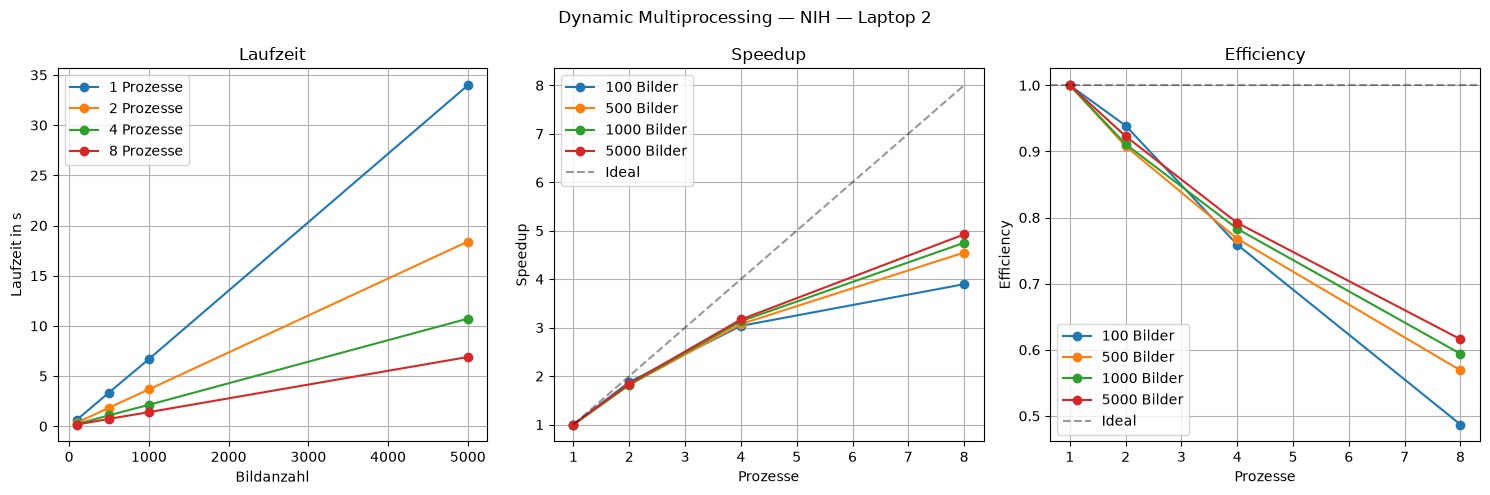

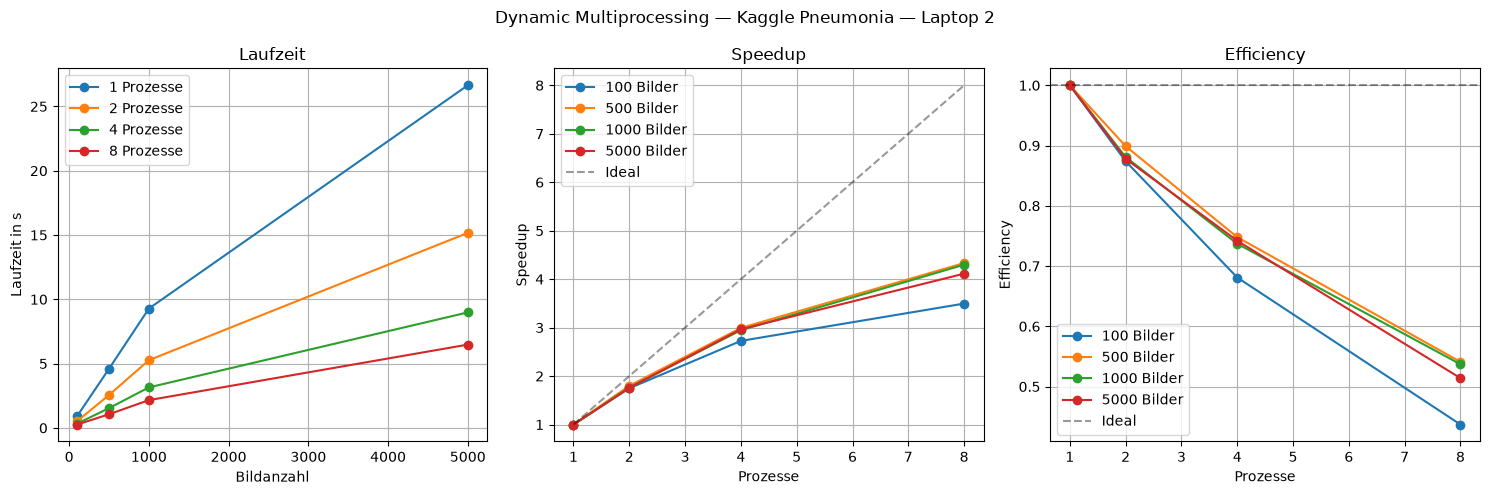

In [7]:
Path("plots").mkdir(exist_ok=True)

for dataset_name in ["NIH", "Kaggle Pneumonia"]:
    sub_ds = df[(df["Datensatz"] == dataset_name) & (df["Variante"] == "Dynamic")]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Dynamic Multiprocessing — {dataset_name} — Laptop {LAPTOP_ID}")

    ax = axes[0]
    for n_proc in PROCESS_COUNTS:
        sub = sub_ds[sub_ds["Prozesse"] == n_proc]
        ax.errorbar(sub["Bilder"], sub["Laufzeit in s"],
                    yerr=sub["Std"], marker="o", capsize=4, label=f"{n_proc} Prozesse")
    ax.set_xlabel("Bildanzahl")
    ax.set_ylabel("Laufzeit in s")
    ax.set_title("Laufzeit")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.errorbar(sub["Prozesse"], sub["Speedup"],
                        yerr=sub["Std"], marker="o", capsize=4, label=f"{n_img} Bilder")
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "k--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.set_title("Speedup")
    ax.legend()
    ax.grid(True)

    ax = axes[2]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.errorbar(sub["Prozesse"], sub["Efficiency"],
                        yerr=sub["Std"], marker="o", capsize=4, label=f"{n_img} Bilder")
    ax.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Efficiency")
    ax.set_title("Efficiency")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    fname = f"{RESULTS_DIR}/dynamic_{dataset_name.lower().replace(' ', '_')}_laptop{LAPTOP_ID}.png"
    plt.savefig(fname, dpi=150)
   # plt.show()


# Dynamic vs. Dynamic True
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Dynamic vs. Dynamic True — Laptop {LAPTOP_ID}")

for ax, dataset_name in zip(axes, ["NIH", "Kaggle Pneumonia"]):
    for variant, color, marker in [
        ("Dynamic",      "darkorange", "o"),
        ("Dynamic True", "purple",     "s"),
    ]:
        sub = df[
            (df["Variante"]  == variant) &
            (df["Datensatz"] == dataset_name) &
            (df["Bilder"]    == 1000)
        ]
        if not sub.empty:
            ax.errorbar(sub["Prozesse"], sub["Laufzeit in s"],
                        yerr=sub["Std"], color=color, marker=marker,
                        capsize=4, label=variant)
    ax.set_title(dataset_name)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Laufzeit in s")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
fname = f"{RESULTS_DIR}/dynamic_vs_true_laptop{LAPTOP_ID}.png"
plt.savefig(fname, dpi=150)
#plt.show()

1. Beide Datensätze skalieren linear mit der Bildanzahl (=erwartet). Bei NIH ist 8 Prozesse bei 5000 Bildern ~6.5s, bei Kaggle ~6.5s ebenfalls. NIH und Kaggle sind bei Dynamic fast gleich schnell —> das ist der Lastausgleich
2. mehr Bilder = höherer Speedup: bei 5000 Bildern ist der Startup-Overhead relativ kleiner als bei 100 Bildern, deshalb skaliert es besser. Bei 100 Bildern nur ~3.5 Speedup weil der Overhead im Verhältnis zur Arbeit größer ist.
3. Bei 100 Bildern bricht die Efficiency bei 8 Prozessen auf ~50% bei NIH und fast 0% bei Kaggle ein -> der Prozess-Startup-Overhead überwiegt bei so wenigen Bildern. Bei 5000 Bildern hält die Efficiency bei ~60% NIH und ~52% Kaggle (trotzdem weit entfernt vom Ideal)

#### 6. Idle-Time Analyse
Veranschaulichung der Variation der Laufzeit zwischen den einzelnen Bildern

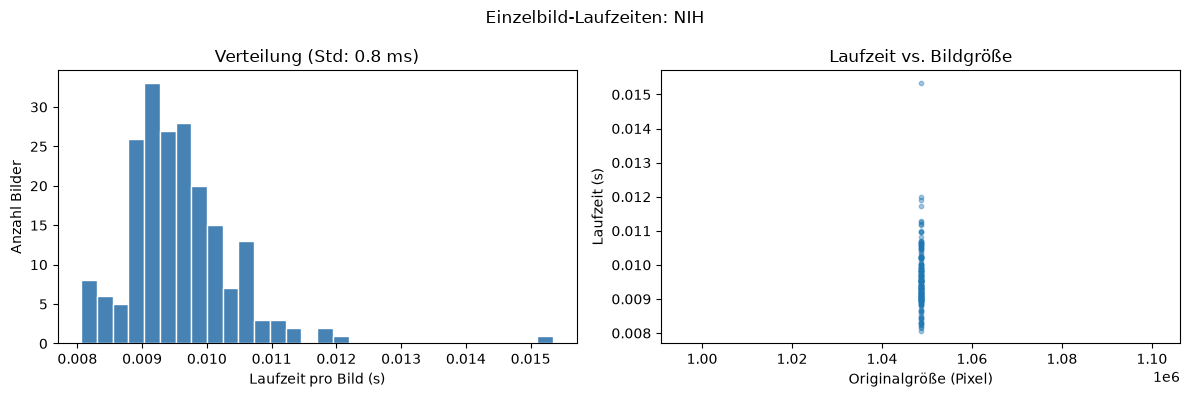

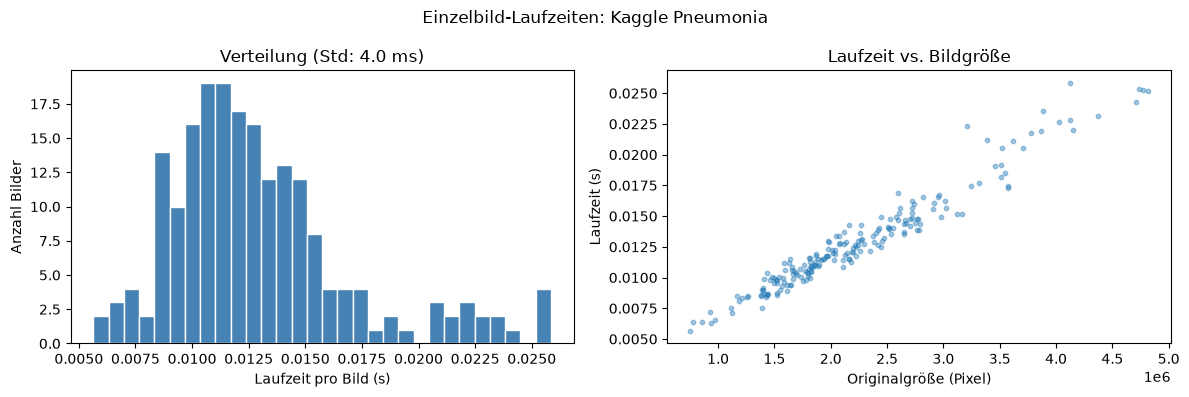

In [8]:
for ds_label, paths in [("NIH", nih_paths[:200]), ("Kaggle Pneumonia", kaggle_paths[:200])]:
    if len(paths) == 0:
        continue

    _, results = run_dynamic(paths, n_processes=4)
    durations  = [r["duration_s"]    for r in results if r["success"]]
    sizes      = [r["original_size"] for r in results if r["success"] and r["original_size"]]
    pixels     = [w * h for w, h in sizes]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Einzelbild-Laufzeiten: {ds_label}")

    axes[0].hist(durations, bins=30, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Laufzeit pro Bild (s)")
    axes[0].set_ylabel("Anzahl Bilder")
    axes[0].set_title(f"Verteilung (Std: {np.std(durations)*1000:.1f} ms)")

    if pixels:
        axes[1].scatter(pixels, durations, alpha=0.4, s=10)
        axes[1].set_xlabel("Originalgröße (Pixel)")
        axes[1].set_ylabel("Laufzeit (s)")
        axes[1].set_title("Laufzeit vs. Bildgröße")

    plt.tight_layout()
    fname = f"{RESULTS_DIR}/idle_{ds_label.lower().replace(' ', '_')}_laptop{LAPTOP_ID}.png"
    plt.savefig(fname, dpi=150)
    #plt.show()

1. NIH: alle Punkte auf einer senkrechten Linie bei ~1.05 Megapixel. Alle Originalbilder gleich groß -> gleiche Laufzeit -> schmale Verteilung
2. Kaggle: Punkte von ~800k bis ~5 Megapixel mit klarer Steigung. Große Originalbilder dauern länger -> breite Verteilung